# S02 — F6 per-cell feature extractor

Interpretable 41-dim per-cell feature vector for CZ or HCR_GFP modality. Rotation-invariant after the 180° XY prior is applied.

In [1]:
import sys, warnings, time
warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path('/root/capsule/code/full_automatic_execution_01').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, '/root/capsule/code/dev_code')

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.linalg import norm

from benchmark_data_loader import load_subject
from lib.cell_features import extract_cell_features, invariant_feature_mask

In [2]:
s = load_subject('788406')
t0 = time.time()
Fc, names, ic = extract_cell_features(s, 'cz')
print(f'CZ: {Fc.shape} in {time.time()-t0:.1f}s')
t0 = time.time()
Fg, names2, ig = extract_cell_features(s, 'hcr_gfp')
print(f'HCR_GFP: {Fg.shape} in {time.time()-t0:.1f}s')
print(f'Feature names ({len(names)}):')
for n in names: print(' ', n)

CZ: (932, 41) in 42.4s
HCR_GFP: (17427, 41) in 7.8s
Feature names (41):
  knn_elev_0
  knn_elev_1
  knn_elev_2
  knn_elev_3
  knn_elev_4
  knn_elev_5
  knn_azdiff_0
  knn_azdiff_1
  knn_azdiff_2
  knn_azdiff_3
  knn_azdiff_4
  knn_azdiff_5
  depth_um
  depth_rank_ring
  depth_rank_fullpop
  count_gfp_30um
  count_all_30um
  density_ratio_30um
  dist_knn_z_1
  dist_knn_z_2
  dist_knn_z_3
  dist_knn_z_4
  dist_knn_z_5
  dist_knn_z_6
  dist_knn_z_7
  dist_knn_z_8
  dist_knn_z_9
  dist_knn_z_10
  vol_ratio
  gfp_density
  gfp_count
  gfp_log1p_count
  gfp_mean_minus_bg
  layer_hist_0
  layer_hist_1
  layer_hist_2
  layer_hist_3
  layer_hist_4
  layer_hist_5
  layer_hist_6
  layer_hist_7


In [3]:
# Feature invariance mask
inv = invariant_feature_mask(names)
print(f'Invariant features: {int(inv.sum())}/{len(names)}')
for n, m in zip(names, inv):
    print(f'  {n:<22} {"INV" if m else "abs"}')


Invariant features: 37/41
  knn_elev_0             INV
  knn_elev_1             INV
  knn_elev_2             INV
  knn_elev_3             INV
  knn_elev_4             INV
  knn_elev_5             INV
  knn_azdiff_0           INV
  knn_azdiff_1           INV
  knn_azdiff_2           INV
  knn_azdiff_3           INV
  knn_azdiff_4           INV
  knn_azdiff_5           INV
  depth_um               abs
  depth_rank_ring        INV
  depth_rank_fullpop     INV
  count_gfp_30um         abs
  count_all_30um         abs
  density_ratio_30um     INV
  dist_knn_z_1           INV
  dist_knn_z_2           INV
  dist_knn_z_3           INV
  dist_knn_z_4           INV
  dist_knn_z_5           INV
  dist_knn_z_6           INV
  dist_knn_z_7           INV
  dist_knn_z_8           INV
  dist_knn_z_9           INV
  dist_knn_z_10          INV
  vol_ratio              abs
  gfp_density            INV
  gfp_count              INV
  gfp_log1p_count        INV
  gfp_mean_minus_bg      INV
  layer_hist_0   

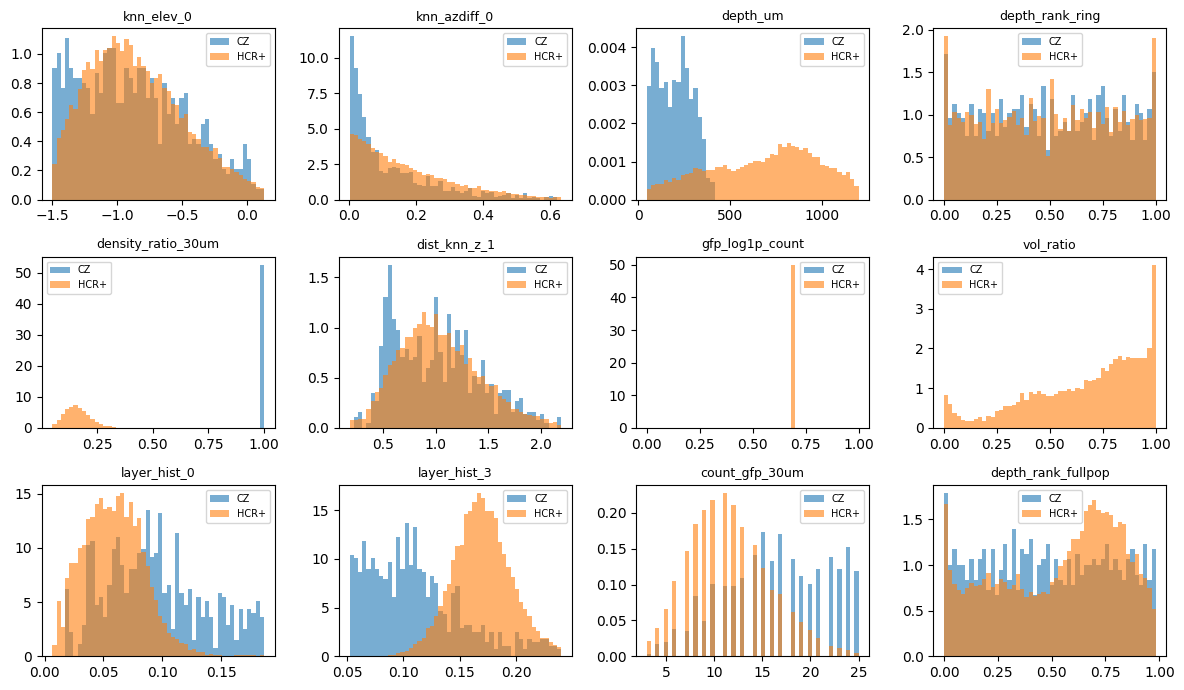

In [4]:
# Feature distribution plots for a subset
import numpy as np
fig, axes = plt.subplots(3, 4, figsize=(12, 7))
plot_features = ['knn_elev_0','knn_azdiff_0','depth_um','depth_rank_ring',
                 'density_ratio_30um','dist_knn_z_1','gfp_log1p_count','vol_ratio',
                 'layer_hist_0','layer_hist_3','count_gfp_30um','depth_rank_fullpop']
for ax, fname in zip(axes.ravel(), plot_features):
    j = names.index(fname)
    cz_v = Fc[:, j]; hcr_v = Fg[:, j]
    cz_v = cz_v[np.isfinite(cz_v)]; hcr_v = hcr_v[np.isfinite(hcr_v)]
    if len(cz_v) and len(hcr_v):
        lo, hi = np.nanpercentile(np.concatenate([cz_v, hcr_v]), [1, 99])
    else:
        lo, hi = 0, 1
    if not np.isfinite([lo,hi]).all() or lo == hi: lo, hi = 0, 1
    ax.hist(cz_v, bins=50, alpha=0.6, label='CZ', density=True, range=(lo,hi))
    ax.hist(hcr_v, bins=50, alpha=0.6, label='HCR+', density=True, range=(lo,hi))
    ax.set_title(fname, fontsize=9); ax.set_xlabel('')
    ax.legend(fontsize=7, loc='best')
fig.tight_layout()
fig.savefig(str(ROOT/'sessions'/'02_F6_per_cell_features'/'figures'/'feature_distributions.png'), dpi=100)
plt.show()

shared invariant cols: 32
GT pairs: 784
GT median cosine  0.087
RAND median cosine -0.005


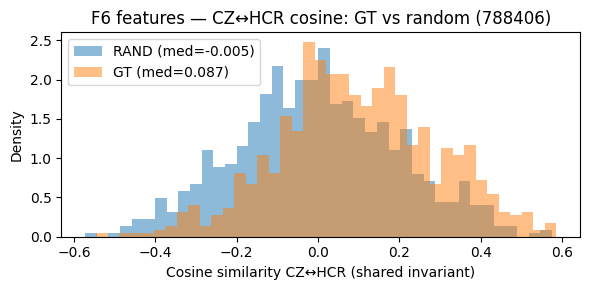

In [5]:
# GT vs random cosine separation on shared-invariant finite features
keep = inv & ~np.isnan(Fc).any(0) & ~np.isnan(Fg).any(0)
print('shared invariant cols:', int(keep.sum()))
Fck = Fc[:, keep]; Fgk = Fg[:, keep]
mu = np.nanmean(Fgk, axis=0); sd = np.nanstd(Fgk, axis=0) + 1e-6
Fcz = (Fck - mu) / sd
Fgz = (Fgk - mu) / sd

gt = s.coreg_table
cz_map = {cz: r for r, cz in enumerate(ic)}
hcr_map = {hcr: r for r, hcr in enumerate(ig)}
pairs = [(cz_map[cz], hcr_map[hcr]) for cz, hcr in zip(gt['cz_id'], gt['hcr_id']) if cz in cz_map and hcr in hcr_map]
print('GT pairs:', len(pairs))
rng = np.random.default_rng(0)
cs_gt, cs_rand = [], []
for ci, hi in pairs:
    a = Fcz[ci]; b = Fgz[hi]
    cs_gt.append((a@b)/(norm(a)*norm(b)+1e-9))
    rh = rng.integers(len(Fgz))
    br = Fgz[rh]
    cs_rand.append((a@br)/(norm(a)*norm(br)+1e-9))
cs_gt = np.asarray(cs_gt); cs_rand = np.asarray(cs_rand)
print(f'GT median cosine  {np.median(cs_gt):.3f}')
print(f'RAND median cosine {np.median(cs_rand):.3f}')
fig, ax = plt.subplots(figsize=(6,3))
ax.hist(cs_rand, bins=40, alpha=0.5, label=f'RAND (med={np.median(cs_rand):.3f})', density=True)
ax.hist(cs_gt, bins=40, alpha=0.5, label=f'GT (med={np.median(cs_gt):.3f})', density=True)
ax.set_xlabel('Cosine similarity CZ↔HCR (shared invariant)'); ax.set_ylabel('Density')
ax.set_title('F6 features — CZ↔HCR cosine: GT vs random (788406)')
ax.legend()
fig.tight_layout()
fig.savefig(str(ROOT/'sessions'/'02_F6_per_cell_features'/'figures'/'cosine_gt_vs_random.png'), dpi=120)
plt.show()

### Takeaway
- Features are extracted in a few seconds per subject after the one-time surface-fit cache warm-up.
- Raw CZ↔HCR cosine on shared invariant features shows a **weak but real** separation (GT median ≈ 0.09 vs RAND ≈ 0).
- This is a *lower bound* on utility — downstream matchers (G1 Sinkhorn, P1 TEASER, QF1 GBT) combine F6 with geometric consistency, giving much stronger discrimination than raw cosine.